# Few-Shot Bayesian Calibration: đếm hạt lúa trong ly (Colab)

Notebook chạy **phương pháp đề xuất + 16 baseline** trên dữ liệu của repo `DATASET_BUILDER`.

- Mô hình: `log N = phys(x) + b_lot + g(z)`, cập nhật Normal-Inverse-Gamma cho từng lot, khoảng 90% hiệu chuẩn bằng nested leave-one-source-lot-out.
- Giao thức: Leave-One-Lot-Out (lot = loại ly), K cốc support, query là các cốc khác.
- Thời gian: khoảng 4 phút với `REPS=50` trên CPU. Đặt `FAST=True` để bỏ RF/GB/GP (vài giây).

## 1. Cài đặt và tải dữ liệu

In [ ]:
!git clone -q https://github.com/NguyenMinhTri24072005/DATASET_BUILDER.git 2>/dev/null || echo "repo đã có"
%cd DATASET_BUILDER
!pip -q install joblib tabulate

/content/DATASET_BUILDER


## 2. Ghi code phương pháp + baseline ra file

In [ ]:
%%writefile rice_fewshot_v2.py
#!/usr/bin/env python3
"""rice_fewshot_v2.py -- Few-Shot Bayesian Calibration for bulk rice grain counting (proposed method + baselines)

Model      log N = phys(x) + b_lot + g(z)
           phys = log V_bulk - log V_g   (vision geometry)      or   log W   (weight sensor)
Proposed   g(z): shared ridge residual model, fitted within-lot on SOURCE lots, frozen at adaptation
           b_lot ~ N(b0, tau^2) from source lots -> conjugate posterior from K labelled support cups
           noise var_i = s0^2 + sg^2 / n_i   (n_i = whole grains measured: quality-aware)
           predictive lognormal; 90% interval CALIBRATED by nested leave-one-source-lot-out (no target data used)
Protocol   Leave-One-Lot-Out (lot = cup type; no variety label in data). Support/query = different physical cups.
           Identical random supports for every method. Cups with invalid weight (> 0.1 g/grain) dropped for all.

v2 changes vs v1: calibrated intervals (lambda), posterior is returned (no hidden state), K-free baselines cached
per lot, joblib parallelism over draws, optional TabPFN, --fast mode, plots, paired-test CSV.

usage:   python rice_fewshot_v2.py --csv 4_Final_Dataset/final_regression_dataset.csv --reps 50 [--fast] [--tabpfn]
"""
from __future__ import annotations
import argparse, os, time, warnings
from dataclasses import dataclass, field
import numpy as np, pandas as pd
from joblib import Parallel, delayed
from scipy.optimize import nnls
from scipy.stats import norm, t as student_t
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
warnings.filterwarnings("ignore")

Z90 = norm.ppf(0.95)
IMG = ["Whole_Grains_Count", "Uniformity_Rate_Pct", "Grain_Length_mm_Mean", "Grain_Width_mm_Mean",
       "Grain_Thickness_mm_Mean", "Grain_Area_mm2_Mean", "Grain_Volume_mm3_Mean", "Grain_Length_mm_Std", "Grain_Width_mm_Std"]
BULK = ["lV", "lD", "lH"]
ALL = BULK + IMG


@dataclass
class Config:
    csv: str = "4_Final_Dataset/final_regression_dataset.csv"
    reps: int = 50
    Ks: tuple = (0, 1, 3, 5, 10, 20)
    seed: int = 0
    n_jobs: int = -1
    out: str = "results_v2"
    drop_bad_weight: bool = True
    fast: bool = False          # skip slow baselines (RF, GB, GP)
    tabpfn: bool = False        # add TabPFN baseline (needs `pip install tabpfn`, GPU recommended)
    min_query: int = 5
    support_weight: float = 10.0
    ref: str = "Ours+W (main): log W, g(z)=W+V_bulk"   # reference for paired tests


# ============================================================ 1. DATA
def build_cups(path: str, drop_bad_weight: bool = True) -> pd.DataFrame:
    d = pd.read_csv(path)
    d["n"] = d["Whole_Grains_Filtered_Count"].clip(lower=1)
    d["nlvg"] = d["n"] * np.log(d["Mean_Clean_Grain_Volume_mm3"])
    g = d.groupby("Physical_Sample_ID")
    c = g.agg(N=("Actual_Count", "first"), V=("Bulk_Rice_Volume_mm3", "first"), D=("Inner_Diameter_mm", "first"),
              Hr=("Rice_Height_mm", "first"), W=("Weight_g", "first"), phys=("Physical_Estimated_Seeds", "mean"),
              n=("n", "sum"), nlvg=("nlvg", "sum"), views=("n", "size"), **{k: (k, "mean") for k in IMG}).reset_index()
    c = c.rename(columns={"Physical_Sample_ID": "cup"})
    c["o"] = c.nlvg / c.n                                   # visual log V_g, grain-count weighted over views
    c["y"], c["lV"], c["lD"], c["lH"] = np.log(c.N), np.log(c.V), np.log(c.D), np.log(c.Hr)
    c["lasp"], c["lW"], c["lphys"] = np.log(c.Hr / c.D), np.log(c.W), np.log(c.phys)
    c["lot"] = c.D.round().astype(int)                      # 17.8, 22.8, {32.6, 32.8}, 41.5 -> 4 lots
    if drop_bad_weight:
        bad = c.W / c.N > 0.1
        print(f"excluded (invalid weight): {int(bad.sum())} cups")
        c = c[~bad]
    c = c.reset_index(drop=True)
    print(f"cups: {len(c)} | lots: {c.lot.value_counts().sort_index().to_dict()}")
    return c


# ============================================================ 2. PROPOSED METHOD
class BayesLotCalibrator:
    def __init__(self, z_cols=("o",), use_vg=True, phys_col="lV", fit_g=True, quality=True, alpha=1.0,
                 tau_floor=0.10, calibrate=True, cal_Ks=(1, 3, 5), cal_reps=20, seed=0,
                 g_mode="within", nig=True, nu0=4.0):
        self.g_mode, self.nig, self.nu0 = g_mode, nig, nu0
        self.z, self.use_vg, self.phys_col, self.fit_g = list(z_cols), use_vg, phys_col, fit_g and len(z_cols) > 0
        self.quality, self.alpha, self.tau_floor = quality, alpha, tau_floor
        self.calibrate, self.cal_Ks, self.cal_reps, self.seed = calibrate, cal_Ks, cal_reps, seed
        self.lam = 1.0

    def _clone(self, calibrate=False):
        return BayesLotCalibrator(self.z, self.use_vg, self.phys_col, self.fit_g, self.quality, self.alpha,
                                  self.tau_floor, calibrate, self.cal_Ks, self.cal_reps, self.seed,
                                  self.g_mode, self.nig, self.nu0)

    # --- pieces
    def _phys(self, c): return c[self.phys_col].values - (c.o.values if self.use_vg else 0.0)
    def _var(self, c): return self.s0 + self.sg / c.n.values
    def _gz(self, c):
        if self.g is None: return np.zeros(len(c))
        return self.g.predict((c[self.z].values - self.mu_z) / self.sd_z)

    def _fit_core(self, src):
        r = src.y.values - self._phys(src); lots = src.lot.values; U = np.unique(lots)
        if self.fit_g:
            Z = src[self.z].values; self.mu_z, self.sd_z = Z.mean(0), Z.std(0) + 1e-9
            Zs = (Z - self.mu_z) / self.sd_z; Zw, rw = Zs.copy(), r - r.mean()
            if self.g_mode == "within":                     # within-lot estimator: g does not absorb lot offsets
                for l in U:
                    m = lots == l; Zw[m] -= Zs[m].mean(0); rw[m] = r[m] - r[m].mean()
            self.g = Ridge(alpha=self.alpha, fit_intercept=False).fit(Zw, rw); gz = self.g.predict(Zs)
        else:
            self.g, gz = None, np.zeros(len(src))
        res = r - gz
        bl = np.array([res[lots == l].mean() for l in U])
        self.b0 = bl.mean()
        self.tau = max(bl.std(ddof=1) if len(bl) > 1 else 0.0, self.tau_floor)
        e = np.concatenate([res[lots == l] - res[lots == l].mean() for l in U])
        nn = np.concatenate([src.n.values[lots == l] for l in U])
        if self.quality:
            (s0, sg), _ = nnls(np.c_[np.ones(len(e)), 1.0 / nn], e ** 2); self.s0, self.sg = max(s0, 1e-4), sg
        else:
            self.s0, self.sg = float(np.mean(e ** 2)), 0.0
        return self

    def _nested_lambda(self, src):
        """variance inflation so that the 90% interval covers 90% on held-out SOURCE lots"""
        rng = np.random.default_rng(self.seed); zs = []
        for l in np.unique(src.lot):
            inner = self._clone()._fit_core(src[src.lot != l]); tgt = src[src.lot == l].reset_index(drop=True)
            for K in self.cal_Ks:
                if len(tgt) - K < 3: continue
                for _ in range(self.cal_reps):
                    i = rng.permutation(len(tgt)); s, q = tgt.iloc[i[:K]], tgt.iloc[i[K:]]
                    m, sd, dof = inner._moments(q, inner.posterior(s))
                    zq = Z90 if not np.isfinite(dof) else student_t.ppf(0.95, dof)
                    zs.append(np.abs(q.y.values - m) / (sd * zq / Z90))
        return max(1.0, float(np.quantile(np.concatenate(zs), 0.90)) / Z90) if zs else 1.0

    # --- public API
    def fit_source(self, src):
        self._fit_core(src)
        if self.calibrate and src.lot.nunique() >= 3: self.lam = self._nested_lambda(src)
        return self

    def posterior(self, sup):
        """Normal-Inverse-Gamma update. Noise of lot: var_i = sigma2_lot * h_i, h_i = var_i / s_ref (quality weights).
        Prior: sigma2_lot ~ IG(nu0/2, nu0*s_ref/2), b | sigma2 ~ N(b0, sigma2 * tau^2 / s_ref).
        With nig=False sigma2_lot is fixed at s_ref (plain Normal model, v1 behaviour)."""
        s_ref = self.s0 + self.sg / 14.0                    # reference variance at a typical cup (n ~ 14 grains)
        k0 = s_ref / self.tau ** 2
        a0, b0 = self.nu0 / 2.0, self.nu0 * s_ref / 2.0
        if len(sup) == 0: return dict(m=self.b0, k=k0, a=a0, b=b0, s_ref=s_ref)
        rs = sup.y.values - self._phys(sup) - self._gz(sup); w = s_ref / self._var(sup)
        kn = k0 + w.sum(); mn = (k0 * self.b0 + (w * rs).sum()) / kn
        an = a0 + len(sup) / 2.0
        bn = b0 + 0.5 * ((w * rs ** 2).sum() + k0 * self.b0 ** 2 - kn * mn ** 2)
        return dict(m=mn, k=kn, a=an, b=max(bn, 1e-12), s_ref=s_ref)

    def _moments(self, q, post):
        h = self._var(q) / post["s_ref"]
        if self.nig: sig2, dof = post["b"] / post["a"], 2.0 * post["a"]
        else: sig2, dof = post["s_ref"], np.inf
        sd = np.sqrt(sig2 * (h + 1.0 / post["k"])) * self.lam
        return self._phys(q) + self._gz(q) + post["m"], sd, dof

    def predict(self, q, post):
        m, sd, dof = self._moments(q, post)
        zq = Z90 if not np.isfinite(dof) else student_t.ppf(0.95, dof)
        return np.exp(m), np.exp(m - zq * sd), np.exp(m + zq * sd)


MAIN = "Ours+W (main): log W, g(z)=W+V_bulk"
OURS = {
    # ---- with weight sensor (main proposal) + ablations
    MAIN:                                   dict(z_cols=("lW", "lV"), use_vg=False, phys_col="lW", g_mode="pooled"),
    "Ours+W ablation: no NIG (fixed noise)": dict(z_cols=("lW", "lV"), use_vg=False, phys_col="lW", g_mode="pooled", nig=False),
    "Ours+W ablation: uncalibrated (lam=1)": dict(z_cols=("lW", "lV"), use_vg=False, phys_col="lW", g_mode="pooled", calibrate=False),
    "Ours+W ablation: within-lot g(z)":     dict(z_cols=("lW", "lV"), use_vg=False, phys_col="lW", g_mode="within"),
    "Ours+W ablation: + V_g in g(z)":       dict(z_cols=("lW", "lV", "o"), use_vg=False, phys_col="lW", g_mode="pooled"),
    "Ours+W ablation: scale only (g=0)":    dict(z_cols=(), fit_g=False, use_vg=False, phys_col="lW"),
    # ---- vision + cup geometry only (no weight sensor) + ablations
    "Ours-V (no scale): g(z)=V_g":          dict(z_cols=("o",)),
    "Ours-V ablation: g=0":                 dict(z_cols=(), fit_g=False),
    "Ours-V ablation: no V_g term":         dict(z_cols=("lD", "lasp"), use_vg=False),
    "Ours-V ablation: uncalibrated":        dict(z_cols=("o",), calibrate=False),
}


# ============================================================ 3. BASELINES  fn(src, sup, q, cfg) -> N_hat
def _pooled(s, u, cols, est, sw):
    d = pd.concat([s, u]); w = np.r_[np.ones(len(s)), np.full(len(u), sw)]
    if hasattr(est, "steps"): est.fit(d[cols], d.y, **{f"{est.steps[-1][0]}__sample_weight": w})
    else: est.fit(d[cols], d.y, sample_weight=w)
    return est
def _lin(s, cols): return LinearRegression().fit(s[cols], s.y)
def _gp(): return make_pipeline(StandardScaler(), GPR(C(1.0) * RBF(2.0) + WhiteKernel(1e-2, (1e-6, 1)), normalize_y=True, random_state=0))

def P0(s, u, q, cfg): return np.exp(q.lV - q.o + (s.y - s.lV + s.o).mean()).values
def P1(s, u, q, cfg): return q.phys.values
def P2(s, u, q, cfg): return np.exp(q.lphys + (u.y - u.lphys).mean()).values
def V1(s, u, q, cfg): return np.exp(make_pipeline(StandardScaler(), Ridge(1.0)).fit(s[IMG], s.y).predict(q[IMG]))
def W1(s, u, q, cfg): return np.exp(q.lW + (s.y - s.lW).mean()).values
def W2(s, u, q, cfg): return np.exp(q.lW + (u.y - u.lW).mean()).values
def W3(s, u, q, cfg): return np.exp(_lin(s, ["lW", "lV"]).predict(q[["lW", "lV"]]))
def W4(s, u, q, cfg):
    m = _lin(s, ["lW", "lV"]); return np.exp(m.predict(q[["lW", "lV"]]) + (u.y - m.predict(u[["lW", "lV"]])).mean())
def L1(s, u, q, cfg): return np.exp(_lin(s, ["lV"]).predict(q[["lV"]]))
def L2(s, u, q, cfg):
    m = _lin(s, ["lV"]); return np.exp(m.predict(q[["lV"]]) + (u.y - m.predict(u[["lV"]])).mean())
def L3(s, u, q, cfg): return np.exp(LinearRegression().fit(u[["lV"]], u.y).predict(q[["lV"]]))
def T1(s, u, q, cfg): return np.exp(_pooled(s, u, ALL, make_pipeline(StandardScaler(), Ridge(1.0)), cfg.support_weight).predict(q[ALL]))
def T2(s, u, q, cfg): return np.exp(_pooled(s, u, ALL, RandomForestRegressor(100, min_samples_leaf=2, random_state=0, n_jobs=1), cfg.support_weight).predict(q[ALL]))
def T3(s, u, q, cfg): return np.exp(_pooled(s, u, ALL, GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=0), cfg.support_weight).predict(q[ALL]))
def G1(s, u, q, cfg): return np.exp(_gp().fit(u[["lV"]], u.y).predict(q[["lV"]]))
def G2(s, u, q, cfg):
    d = pd.concat([s, u]); m = _lin(s, ["lV"]); g = _gp().fit(d[["lV"]], d.y - m.predict(d[["lV"]]))
    return np.exp(m.predict(q[["lV"]]) + g.predict(q[["lV"]]))
def TP(s, u, q, cfg):
    from tabpfn import TabPFNRegressor
    d = pd.concat([s, u]); return np.exp(TabPFNRegressor().fit(d[ALL].values, d.y.values).predict(q[ALL].values))

# (group, name, fn, min_K, k_free, slow)
BASELINES = [
    ("Physics-based",    "Physics V_bulk/V_g, source offset",          P0, 0, True,  False),
    ("Physics-based",    "Repo physical estimate",                     P1, 0, True,  False),
    ("Physics-based",    "Repo physical estimate + MLE scale",         P2, 1, False, False),
    ("Vision-only",      "Ridge, image features only",                 V1, 0, True,  False),
    ("Weight-based",     "Weight only, source scale",                  W1, 0, True,  False),
    ("Weight-based",     "Weight only + MLE scale",                    W2, 1, False, False),
    ("Weight-based",     "Weight + V_bulk log-log",                    W3, 0, True,  False),
    ("Weight-based",     "Weight + V_bulk log-log + MLE shift",        W4, 1, False, False),
    ("Volume log-log",   "V_bulk log-log, pooled source",              L1, 0, True,  False),
    ("Volume log-log",   "V_bulk log-log, source slope + MLE shift",   L2, 1, False, False),
    ("Volume log-log",   "V_bulk log-log, support-only",               L3, 3, False, False),
    ("Tabular ML",       "Ridge, all features, pooled + support",      T1, 0, False, False),
    ("Tabular ML",       "Random Forest, pooled + support",            T2, 0, False, True),
    ("Tabular ML",       "Gradient Boosting, pooled + support",        T3, 0, False, True),
    ("Gaussian process", "GP on V_bulk, support-only",                 G1, 3, False, True),
    ("Gaussian process", "GP residual on source log-log, pooled+sup.", G2, 0, False, True),
]


# ============================================================ 4. PROTOCOL
def metrics(N, p, lo=None, hi=None):
    e = N - p
    out = dict(MAE=np.mean(np.abs(e)), MSE=np.mean(e ** 2), RMSE=np.sqrt(np.mean(e ** 2)),
               MAPE=100 * np.mean(np.abs(e) / N), R2=1 - np.sum(e ** 2) / np.sum((N - N.mean()) ** 2))
    if lo is not None:
        out["Cov90"] = 100 * np.mean((N >= lo) & (N <= hi)); out["Width%"] = 100 * np.mean((hi - lo) / N)
    return out

def _eval_draw(lot, K, rep, tgt, src, sup_idx, ours, cache, bl, cfg):
    mask = np.zeros(len(tgt), bool); mask[sup_idx] = True
    sup, q = tgt[mask], tgt[~mask]; rows = []
    for g, n, fn, mk, kfree, _ in bl:
        if K < mk: continue
        p = cache[n][~mask] if kfree else np.asarray(fn(src, sup, q, cfg))
        rows.append(dict(group=g, model=n, lot=lot, K=K, rep=rep, **metrics(q.N.values, p)))
    for n, m in ours.items():
        p, lo, hi = m.predict(q, m.posterior(sup))
        rows.append(dict(group="Ours", model=n, lot=lot, K=K, rep=rep, **metrics(q.N.values, p, lo, hi)))
    return rows

def run(c: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    bl = [b for b in BASELINES if not (cfg.fast and b[5])]
    if cfg.tabpfn:
        try:
            import tabpfn  # noqa
            bl.append(("Foundation model", "TabPFN, all features, pooled + support", TP, 0, False, True))
        except ImportError:
            print("TabPFN not installed -> skipped")
    rng = np.random.default_rng(cfg.seed); jobs = []
    for lot in sorted(c.lot.unique()):
        tgt = c[c.lot == lot].reset_index(drop=True); src = c[c.lot != lot].reset_index(drop=True)
        t0 = time.time()
        ours = {k: BayesLotCalibrator(**v, seed=cfg.seed).fit_source(src) for k, v in OURS.items()}
        cache = {n: np.asarray(fn(src, tgt.iloc[:0], tgt, cfg)) for g, n, fn, mk, kf, _ in bl if kf}
        lam = ours[MAIN].lam
        print(f"lot {lot}: n_tgt={len(tgt)} n_src={len(src)} fitted in {time.time()-t0:.1f}s (lambda main={lam:.2f})")
        for K in cfg.Ks:
            if len(tgt) - K < cfg.min_query: continue
            for r in range(1 if K == 0 else cfg.reps):
                jobs.append((lot, K, r, tgt, src, rng.permutation(len(tgt))[:K], ours, cache))
    nj = 1 if cfg.tabpfn else cfg.n_jobs
    out = Parallel(n_jobs=nj, batch_size=8)(delayed(_eval_draw)(*j, bl, cfg) for j in jobs)
    return pd.DataFrame([r for rows in out for r in rows])


# ============================================================ 5. REPORT
def report(res: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    os.makedirs(cfg.out, exist_ok=True)
    cols = [c for c in ["MAE", "MSE", "RMSE", "MAPE", "R2", "Cov90", "Width%"] if c in res]
    macro = res.groupby(["group", "model", "K", "lot"])[cols].mean().groupby(["group", "model", "K"]).mean().reset_index()
    res.to_csv(f"{cfg.out}/results_raw.csv", index=False); macro.round(3).to_csv(f"{cfg.out}/results_macro.csv", index=False)
    res.groupby(["model", "K", "lot"])[cols].mean().round(3).to_csv(f"{cfg.out}/results_per_lot.csv")

    Ks = [k for k in (0, 1, 5, 10) if k in cfg.Ks]
    L = ["| Group | Method | " + " | ".join(f"K={k} MAE / RMSE / MAPE%" for k in Ks) + " |", "|" + "---|" * (2 + len(Ks))]
    for g in list(dict.fromkeys(macro.group[macro.group != "Ours"])) + ["Ours"]:
        for m in macro[macro.group == g].model.unique():
            cells = []
            for k in Ks:
                r = macro[(macro.model == m) & (macro.K == k)]
                cells.append("–" if r.empty else f"{r.MAE.iloc[0]:.1f} / {r.RMSE.iloc[0]:.1f} / {r.MAPE.iloc[0]:.2f}")
            L.append(f"| {g} | {m} | {' | '.join(cells)} |")
    cov = macro[macro.group == "Ours"].pivot(index="model", columns="K", values="Cov90").round(1)
    txt = "\n".join(L) + "\n\n90% interval coverage (%)\n\n" + cov.to_markdown() if hasattr(cov, "to_markdown") else "\n".join(L)
    open(f"{cfg.out}/paper_table.md", "w").write(txt); print("\n".join(L)); print("\n90% interval coverage (%)\n", cov.to_string())

    rows = []
    for K in [k for k in (1, 3, 5, 10) if k in cfg.Ks]:
        p = res[res.K == K].groupby(["model", "rep", "lot"]).MAPE.mean().groupby(["model", "rep"]).mean().unstack(0)
        if cfg.ref not in p: continue
        for m in p.columns:
            if m == cfg.ref: continue
            d = (p[m] - p[cfg.ref]).dropna()
            if len(d): rows.append(dict(K=K, model=m, dMAPE=d.mean(), lo95=np.percentile(d, 2.5), hi95=np.percentile(d, 97.5), ref_wins_pct=100 * (d > 0).mean()))
    pt = pd.DataFrame(rows).round(3); pt.to_csv(f"{cfg.out}/paired_tests.csv", index=False)
    print(f"\nPaired MAPE difference vs reference '{cfg.ref}' (positive = reference better)")
    print(pt[pt.K == 5].sort_values("dMAPE").to_string(index=False))

    try:
        import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
        show = [cfg.ref, "Ours-V (no scale): g(z)=V_g", "Weight only + MLE scale",
                "Weight + V_bulk log-log + MLE shift", "V_bulk log-log, support-only", "V_bulk log-log, pooled source",
                "Ridge, all features, pooled + support"]
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
        for m in show:
            s = macro[macro.model == m].sort_values("K")
            if len(s): ax[0].plot(s.K, s.MAPE, marker="o", lw=2.4 if m.startswith("Ours") else 1.2, label=m)
        ax[0].set(xlabel="K support cups", ylabel="MAPE % (log)", yscale="log", title="Leave-one-lot-out (macro avg)"); ax[0].legend(fontsize=7)
        for m in [cfg.ref, "Ours+W ablation: no NIG (fixed noise)", "Ours+W ablation: uncalibrated (lam=1)", "Ours-V (no scale): g(z)=V_g"]:
            s = macro[macro.model == m].sort_values("K")
            if len(s): ax[1].plot(s.K, s.Cov90, marker="o", label=m)
        ax[1].axhline(90, ls="--", c="k"); ax[1].set(xlabel="K", ylabel="coverage %", title="90% interval coverage"); ax[1].legend(fontsize=7)
        plt.tight_layout(); plt.savefig(f"{cfg.out}/curves.png", dpi=150); plt.close()
    except Exception as e:
        print("plot skipped:", e)
    return macro


def main(argv=None):
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--csv", default=Config.csv); ap.add_argument("--reps", type=int, default=Config.reps)
    ap.add_argument("--seed", type=int, default=0); ap.add_argument("--n_jobs", type=int, default=-1)
    ap.add_argument("--out", default=Config.out); ap.add_argument("--fast", action="store_true")
    ap.add_argument("--tabpfn", action="store_true"); ap.add_argument("--keep_bad_weight", action="store_true")
    a = ap.parse_args(argv)
    cfg = Config(csv=a.csv, reps=a.reps, seed=a.seed, n_jobs=a.n_jobs, out=a.out, fast=a.fast, tabpfn=a.tabpfn,
                 drop_bad_weight=not a.keep_bad_weight)
    t0 = time.time(); c = build_cups(cfg.csv, cfg.drop_bad_weight)
    res = run(c, cfg); macro = report(res, cfg)
    print(f"\ndone in {time.time()-t0:.0f}s -> {cfg.out}/")
    return res, macro


if __name__ == "__main__":
    main()

Writing rice_fewshot_v2.py


## 3. Cấu hình và chạy

In [3]:
REPS   = 50      # số lần lặp chọn support ngẫu nhiên cho mỗi K
FAST   = False   # True: bỏ RF / GB / GP để chạy nhanh
TABPFN = False   # True: thêm baseline TabPFN (xem mục 6)
SEED   = 0

import importlib, rice_fewshot_v2 as rf
importlib.reload(rf)
args = ["--csv", "4_Final_Dataset/final_regression_dataset.csv", "--reps", str(REPS), "--seed", str(SEED), "--out", "results_v2"]
if FAST:   args.append("--fast")
if TABPFN: args.append("--tabpfn")
res, macro = rf.main(args)

excluded (invalid weight): 7 cups
cups: 148 | lots: {18: 25, 23: 32, 33: 40, 42: 51}
lot 18: n_tgt=25 n_src=123 fitted in 5.3s (lambda main=1.00)
lot 23: n_tgt=32 n_src=116 fitted in 6.8s (lambda main=1.00)
lot 33: n_tgt=40 n_src=108 fitted in 5.2s (lambda main=1.14)
lot 42: n_tgt=51 n_src=97 fitted in 3.7s (lambda main=1.00)
| Group | Method | K=0 MAE / RMSE / MAPE% | K=1 MAE / RMSE / MAPE% | K=5 MAE / RMSE / MAPE% | K=10 MAE / RMSE / MAPE% |
|---|---|---|---|---|---|
| Gaussian process | GP on V_bulk, support-only | – | – | 14.6 / 20.1 / 11.11 | 7.2 / 9.6 / 5.50 |
| Gaussian process | GP residual on source log-log, pooled+sup. | 10.1 / 13.3 / 5.63 | 10.0 / 13.3 / 5.59 | 10.0 / 13.1 / 5.56 | 9.6 / 12.6 / 5.36 |
| Physics-based | Physics V_bulk/V_g, source offset | 60.1 / 82.0 / 28.78 | 60.2 / 82.0 / 28.78 | 60.5 / 82.3 / 29.02 | 60.0 / 81.1 / 28.78 |
| Physics-based | Repo physical estimate | 53.2 / 76.4 / 26.11 | 53.2 / 76.5 / 26.11 | 53.6 / 76.7 / 26.36 | 53.1 / 75.5 / 26.12 |
| Phy

## 4. Bảng kết quả cho bài báo

In [4]:
from IPython.display import Markdown, Image, display
display(Markdown(open("results_v2/paper_table.md").read()))

| Group | Method | K=0 MAE / RMSE / MAPE% | K=1 MAE / RMSE / MAPE% | K=5 MAE / RMSE / MAPE% | K=10 MAE / RMSE / MAPE% |
|---|---|---|---|---|---|
| Gaussian process | GP on V_bulk, support-only | – | – | 14.6 / 20.1 / 11.11 | 7.2 / 9.6 / 5.50 |
| Gaussian process | GP residual on source log-log, pooled+sup. | 10.1 / 13.3 / 5.63 | 10.0 / 13.3 / 5.59 | 10.0 / 13.1 / 5.56 | 9.6 / 12.6 / 5.36 |
| Physics-based | Physics V_bulk/V_g, source offset | 60.1 / 82.0 / 28.78 | 60.2 / 82.0 / 28.78 | 60.5 / 82.3 / 29.02 | 60.0 / 81.1 / 28.78 |
| Physics-based | Repo physical estimate | 53.2 / 76.4 / 26.11 | 53.2 / 76.5 / 26.11 | 53.6 / 76.7 / 26.36 | 53.1 / 75.5 / 26.12 |
| Physics-based | Repo physical estimate + MLE scale | – | 50.0 / 71.3 / 26.95 | 39.8 / 59.2 / 20.69 | 37.9 / 56.3 / 19.56 |
| Tabular ML | Gradient Boosting, pooled + support | 14.4 / 17.4 / 11.57 | 13.6 / 16.7 / 9.95 | 11.6 / 14.3 / 7.92 | 10.3 / 12.8 / 6.85 |
| Tabular ML | Random Forest, pooled + support | 17.0 / 21.1 / 13.24 | 16.2 / 20.0 / 12.22 | 14.7 / 18.0 / 10.14 | 12.8 / 15.8 / 8.44 |
| Tabular ML | Ridge, all features, pooled + support | 14.3 / 17.9 / 7.47 | 12.4 / 16.1 / 6.94 | 10.1 / 13.5 / 5.81 | 8.9 / 11.7 / 5.10 |
| Vision-only | Ridge, image features only | 89.9 / 106.6 / 77.68 | 89.9 / 106.6 / 77.52 | 89.7 / 106.4 / 76.85 | 89.3 / 105.7 / 76.48 |
| Volume log-log | V_bulk log-log, pooled source | 10.1 / 13.3 / 5.63 | 10.1 / 13.3 / 5.62 | 10.2 / 13.4 / 5.66 | 10.0 / 13.2 / 5.56 |
| Volume log-log | V_bulk log-log, source slope + MLE shift | – | 10.6 / 13.1 / 6.73 | 8.5 / 11.0 / 5.15 | 7.8 / 9.9 / 4.81 |
| Volume log-log | V_bulk log-log, support-only | – | – | 7.5 / 9.4 / 4.97 | 6.7 / 8.4 / 4.32 |
| Weight-based | Weight + V_bulk log-log | 6.7 / 8.0 / 4.03 | 6.7 / 8.0 / 4.04 | 6.8 / 8.0 / 4.07 | 6.7 / 7.9 / 3.98 |
| Weight-based | Weight + V_bulk log-log + MLE shift | – | 3.0 / 3.8 / 2.44 | 2.3 / 3.1 / 1.91 | 2.1 / 2.8 / 1.81 |
| Weight-based | Weight only + MLE scale | – | 3.2 / 4.1 / 2.80 | 2.5 / 3.3 / 2.14 | 2.3 / 3.0 / 2.01 |
| Weight-based | Weight only, source scale | 7.0 / 8.2 / 4.08 | 7.0 / 8.2 / 4.07 | 7.0 / 8.3 / 4.11 | 6.9 / 8.2 / 4.02 |
| Ours | Ours+W (main): log W, g(z)=W+V_bulk | 6.0 / 7.3 / 3.76 | 2.8 / 3.6 / 2.33 | 2.2 / 3.0 / 1.88 | 2.0 / 2.7 / 1.78 |
| Ours | Ours+W ablation: + V_g in g(z) | 7.9 / 9.4 / 4.50 | 3.5 / 4.5 / 2.64 | 2.8 / 3.7 / 2.12 | 2.6 / 3.3 / 2.03 |
| Ours | Ours+W ablation: no NIG (fixed noise) | 6.0 / 7.3 / 3.76 | 2.8 / 3.6 / 2.33 | 2.2 / 3.0 / 1.88 | 2.0 / 2.7 / 1.78 |
| Ours | Ours+W ablation: scale only (g=0) | 6.6 / 7.9 / 3.93 | 3.3 / 4.2 / 2.80 | 2.5 / 3.3 / 2.15 | 2.3 / 3.0 / 2.02 |
| Ours | Ours+W ablation: uncalibrated (lam=1) | 6.0 / 7.3 / 3.76 | 2.8 / 3.6 / 2.33 | 2.2 / 3.0 / 1.88 | 2.0 / 2.7 / 1.78 |
| Ours | Ours+W ablation: within-lot g(z) | 6.1 / 7.7 / 3.53 | 3.9 / 4.9 / 3.11 | 3.3 / 4.3 / 2.53 | 2.9 / 3.8 / 2.32 |
| Ours | Ours-V (no scale): g(z)=V_g | 10.4 / 13.9 / 5.73 | 10.2 / 13.0 / 6.09 | 9.4 / 12.1 / 5.37 | 8.6 / 10.9 / 5.02 |
| Ours | Ours-V ablation: g=0 | 56.8 / 76.8 / 27.28 | 51.2 / 72.3 / 25.53 | 41.0 / 61.2 / 20.92 | 37.5 / 56.6 / 19.35 |
| Ours | Ours-V ablation: no V_g term | 12.7 / 16.6 / 7.71 | 10.8 / 13.6 / 6.91 | 9.3 / 11.9 / 5.71 | 8.5 / 10.7 / 5.36 |
| Ours | Ours-V ablation: uncalibrated | 10.4 / 13.9 / 5.73 | 10.2 / 13.0 / 6.09 | 9.4 / 12.1 / 5.37 | 8.6 / 10.9 / 5.02 |

90% interval coverage (%)

| model                                 |     0 |    1 |    3 |    5 |   10 |   20 |
|:--------------------------------------|------:|-----:|-----:|-----:|-----:|-----:|
| Ours+W (main): log W, g(z)=W+V_bulk   |  99   | 85.4 | 92.8 | 93   | 96   | 95.2 |
| Ours+W ablation: + V_g in g(z)        |  99   | 85.1 | 92.6 | 92.7 | 95.3 | 94.4 |
| Ours+W ablation: no NIG (fixed noise) |  98   | 84.8 | 83.5 | 84.8 | 83.1 | 83.5 |
| Ours+W ablation: scale only (g=0)     | 100   | 81.1 | 90.8 | 92.4 | 95.9 | 94.6 |
| Ours+W ablation: uncalibrated (lam=1) |  99   | 85.4 | 92.5 | 92.6 | 95.5 | 94.9 |
| Ours+W ablation: within-lot g(z)      | 100   | 81.4 | 89.9 | 91.3 | 94.7 | 93.1 |
| Ours-V (no scale): g(z)=V_g           |  99   | 93   | 91.7 | 90.9 | 93.2 | 92.6 |
| Ours-V ablation: g=0                  |  96.4 | 92.6 | 92.4 | 91.2 | 92.6 | 92.7 |
| Ours-V ablation: no V_g term          |  94   | 87.5 | 91.3 | 91.4 | 93.6 | 92.4 |
| Ours-V ablation: uncalibrated         |  99   | 91.7 | 90   | 88.9 | 91.6 | 90.9 |

In [5]:
import pandas as pd
pt = pd.read_csv("results_v2/paired_tests.csv")
display(pt[pt.K == 5].sort_values("dMAPE"))   # dMAPE > 0: phương pháp đề xuất tốt hơn

,K,model,dMAPE,lo95,hi95,ref_wins_pct
54,5,Ours+W ablation: uncalibrated (lam=1),0.000,0.000,0.000,0.0
52,5,Ours+W ablation: no NIG (fixed noise),0.000,0.000,0.000,0.0
70,5,Weight + V_bulk log-log + MLE shift,0.033,-0.099,0.124,80.0
51,5,Ours+W ablation: + V_g in g(z),0.244,0.164,0.318,100.0
71,5,Weight only + MLE scale,0.259,-0.098,0.551,94.0
53,5,Ours+W ablation: scale only (g=0),0.267,0.001,0.494,96.0
55,5,Ours+W ablation: within-lot g(z),0.650,0.451,0.971,100.0
69,5,Weight + V_bulk log-log,2.188,1.349,2.508,100.0
72,5,"Weight only, source scale",2.230,1.423,2.522,100.0
68,5,"V_bulk log-log, support-only",3.085,2.269,4.344,100.0


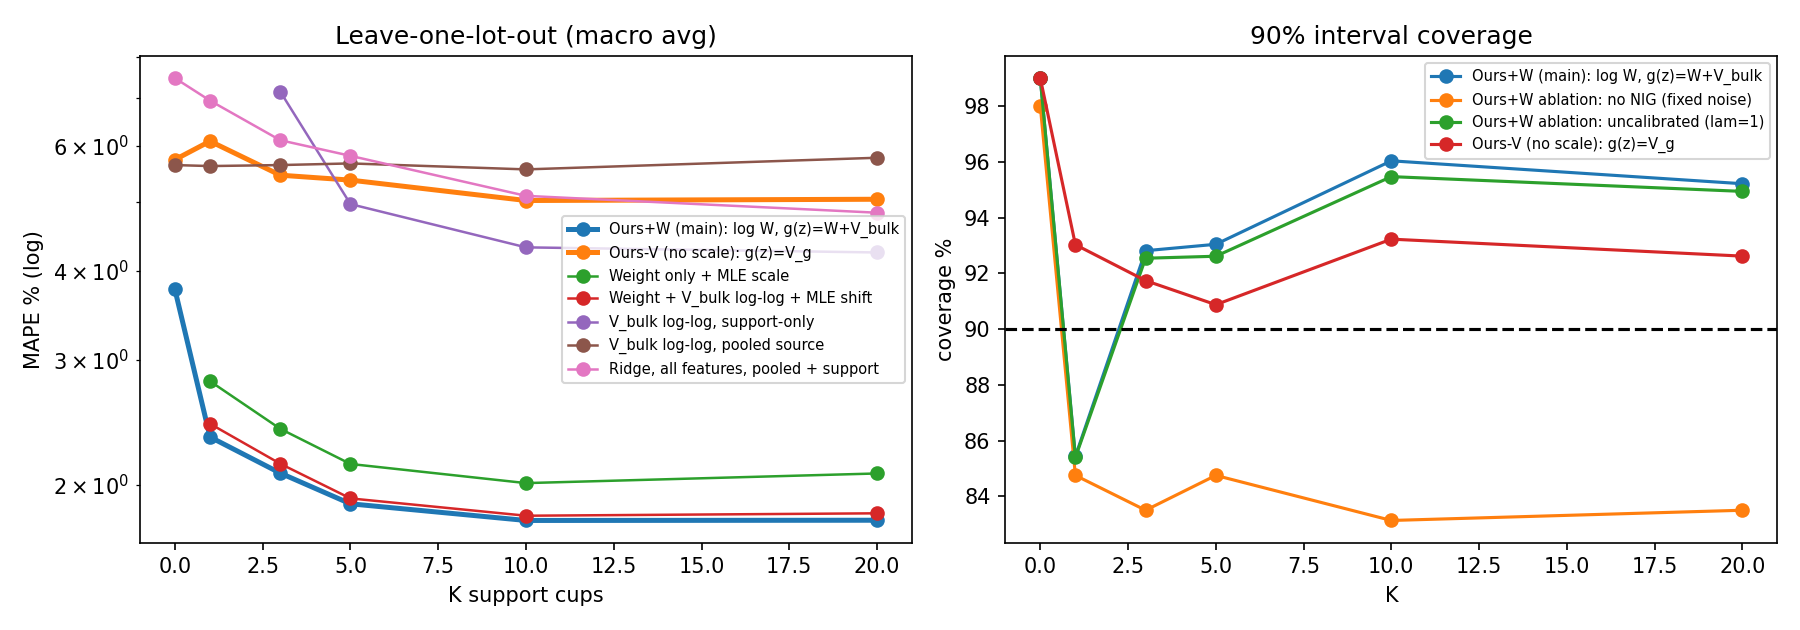

In [6]:
display(Image("results_v2/curves.png"))

## 5. Kết quả theo từng lot

In [7]:
pl = pd.read_csv("results_v2/results_per_lot.csv")
display(pl[pl.K == 5].pivot(index="model", columns="lot", values="MAPE").round(2))

lot,18,23,33,42
model,,,,
"GP on V_bulk, support-only",15.03,3.32,11.92,14.17
"GP residual on source log-log, pooled+sup.",7.13,2.05,6.87,6.20
"Gradient Boosting, pooled + support",14.43,3.51,6.34,7.41
"Ours+W (main): log W, g(z)=W+V_bulk",4.94,0.31,1.50,0.77
Ours+W ablation: + V_g in g(z),5.07,0.32,1.88,1.23
Ours+W ablation: no NIG (fixed noise),4.94,0.31,1.50,0.77
Ours+W ablation: scale only (g=0),6.08,0.43,1.38,0.69
Ours+W ablation: uncalibrated (lam=1),4.94,0.31,1.50,0.77
Ours+W ablation: within-lot g(z),5.95,0.44,2.47,1.26


## 6. (Tuỳ chọn) Baseline TabPFN
Chọn **Runtime > Change runtime type > GPU**, chạy ô dưới, rồi đặt `TABPFN = True` ở mục 3 và giảm `REPS` (ví dụ 10).
Nếu TabPFN yêu cầu đăng nhập hoặc token để tải trọng số, làm theo hướng dẫn hiện ra.

In [8]:
!pip -q install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 45.0 MB/s eta 0:00:00


## 7. Tải kết quả về máy

In [9]:
!zip -qr results_v2.zip results_v2
from google.colab import files
files.download("results_v2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>